In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings
import os
warnings.filterwarnings('ignore')

os.makedirs("../reports/charts", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

RF = 0.065 / 252 
TRADING_DAYS = 252

print("Libraries loaded!")
print(f"Risk-free rate (daily): {RF:.6f}")

Libraries loaded!
Risk-free rate (daily): 0.000258


In [2]:
df_nav = pd.read_csv("../data/processed/nav_40schemes.csv", parse_dates=["date"])
df_bench = pd.read_csv("../data/processed/benchmark_data_cleaned.csv", parse_dates=["date"])

print(f"NAV data: {df_nav.shape}")
print(f"Benchmark data: {df_bench.shape}")
print(f"\nSchemes: {df_nav['scheme_name'].nunique()}")
print(f"Date range: {df_nav['date'].min()} to {df_nav['date'].max()}")
print(f"\nSample:\n{df_nav.head()}")

NAV data: (46000, 6)
Benchmark data: (1305, 3)

Schemes: 40
Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00

Sample:
   amfi_code          scheme_name fund_house   category       date       nav
0     125497  HDFC Top 100 Direct   HDFC AMC  Large Cap 2022-01-03  123.3152
1     125497  HDFC Top 100 Direct   HDFC AMC  Large Cap 2022-01-04  123.8241
2     125497  HDFC Top 100 Direct   HDFC AMC  Large Cap 2022-01-05  124.2759
3     125497  HDFC Top 100 Direct   HDFC AMC  Large Cap 2022-01-06  125.8202
4     125497  HDFC Top 100 Direct   HDFC AMC  Large Cap 2022-01-07  124.9809


Daily returns computed!

Return Statistics:
count    45960.000000
mean         0.000306
std          0.012005
min         -0.051245
25%         -0.007840
50%          0.000330
75%          0.008463
max          0.054049
Name: daily_return, dtype: float64


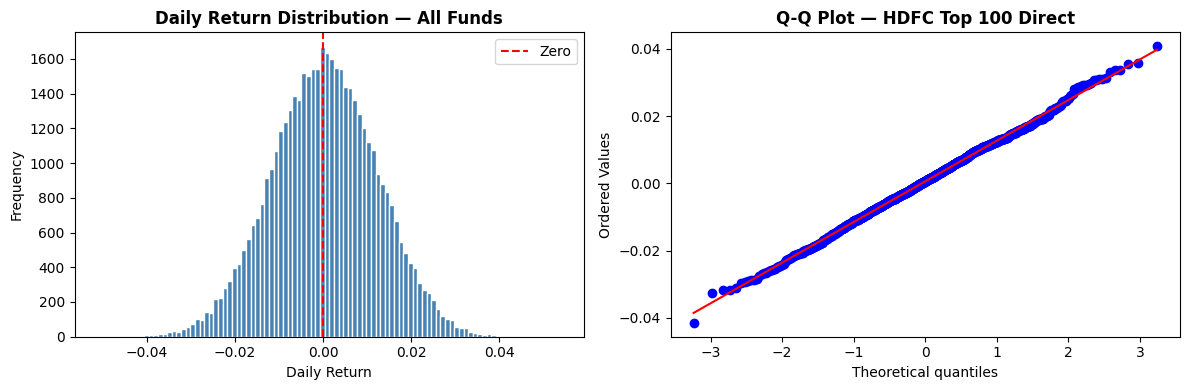

Chart 11 saved!


In [3]:
df_nav = df_nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)

df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()
df_returns = df_nav.dropna(subset=['daily_return']).copy()

print("Daily returns computed!")
print(f"\nReturn Statistics:")
print(df_returns['daily_return'].describe())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df_returns['daily_return'], bins=100, color='steelblue', edgecolor='white')
plt.title("Daily Return Distribution — All Funds", fontweight='bold')
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.axvline(0, color='red', linestyle='--', label='Zero')
plt.legend()

plt.subplot(1, 2, 2)
sample_fund = df_returns[df_returns['scheme_name'] == 'HDFC Top 100 Direct']['daily_return']
stats.probplot(sample_fund, dist="norm", plot=plt)
plt.title("Q-Q Plot — HDFC Top 100 Direct", fontweight='bold')

plt.tight_layout()
plt.savefig("../reports/charts/11_return_distribution.png", dpi=150)
plt.show()
print("Chart 11 saved!")

In [4]:
def compute_cagr(nav_series, years):
    if len(nav_series) < 2:
        return np.nan
    nav_start = nav_series.iloc[0]
    nav_end   = nav_series.iloc[-1]
    if nav_start <= 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / years) - 1

cagr_results = []

for code in df_nav['amfi_code'].unique():
    fund_data = df_nav[df_nav['amfi_code'] == code].sort_values('date')
    name      = fund_data['scheme_name'].iloc[0]
    house     = fund_data['fund_house'].iloc[0]
    category  = fund_data['category'].iloc[0]
    end_date  = fund_data['date'].max()

    start_1yr = end_date - pd.DateOffset(years=1)
    data_1yr  = fund_data[fund_data['date'] >= start_1yr]['nav']
    cagr_1yr  = compute_cagr(data_1yr, 1)

    start_3yr = end_date - pd.DateOffset(years=3)
    data_3yr  = fund_data[fund_data['date'] >= start_3yr]['nav']
    cagr_3yr  = compute_cagr(data_3yr, 3)

    cagr_5yr  = compute_cagr(fund_data['nav'], len(fund_data) / TRADING_DAYS)

    cagr_results.append({
        'amfi_code':   code,
        'scheme_name': name,
        'fund_house':  house,
        'category':    category,
        'cagr_1yr':    round(cagr_1yr * 100, 2),
        'cagr_3yr':    round(cagr_3yr * 100, 2),
        'cagr_5yr':    round(cagr_5yr * 100, 2),
    })

df_cagr = pd.DataFrame(cagr_results)
print("CAGR computed for all 40 funds!")
print(f"\nCAGR Comparison Table:")
print(df_cagr.sort_values('cagr_3yr', ascending=False).to_string(index=False))

CAGR computed for all 40 funds!

CAGR Comparison Table:
 amfi_code                scheme_name  fund_house  category  cagr_1yr  cagr_3yr  cagr_5yr
    120718 Franklin India Smaller Cos Franklin MF Small Cap     36.98     30.41     24.59
    119095    Axis Balanced Advantage     Axis MF    Hybrid     11.93     28.13     17.97
    119598          SBI Magnum Midcap      SBI MF   Mid Cap     44.64     26.80     23.87
    120504    ICICI Prudential Midcap    ICICI MF   Mid Cap     13.56     23.12      9.75
    119093         Axis Midcap Direct     Axis MF   Mid Cap      8.22     17.12     19.80
    118635      Nippon India Balanced   Nippon MF    Hybrid      4.91     15.71      7.51
    119597                DSP Top 100      DSP MF Large Cap     23.51     15.68     14.47
    120505  ICICI Prudential Smallcap    ICICI MF Small Cap      7.53     15.46     17.16
    118633        Nippon India Growth   Nippon MF   Mid Cap     25.66     14.96      5.91
    120468  Mirae Asset Hybrid Equity    Mir

In [5]:
sharpe_results = []

for code in df_returns['amfi_code'].unique():
    fund_ret  = df_returns[df_returns['amfi_code'] == code]['daily_return']
    name      = df_returns[df_returns['amfi_code'] == code]['scheme_name'].iloc[0]

    excess_ret   = fund_ret - RF
    sharpe_ratio = (excess_ret.mean() / excess_ret.std()) * np.sqrt(TRADING_DAYS)

    sharpe_results.append({
        'amfi_code':    code,
        'scheme_name':  name,
        'sharpe_ratio': round(sharpe_ratio, 4)
    })

df_sharpe = pd.DataFrame(sharpe_results).sort_values('sharpe_ratio', ascending=False)
df_sharpe['sharpe_rank'] = range(1, len(df_sharpe) + 1)

print("Sharpe Ratio computed!")
print("\nTop 10 Funds by Sharpe Ratio:")
print(df_sharpe.head(10).to_string(index=False))

Sharpe Ratio computed!

Top 10 Funds by Sharpe Ratio:
 amfi_code                scheme_name  sharpe_ratio  sharpe_rank
    120718 Franklin India Smaller Cos        0.9193            1
    119598          SBI Magnum Midcap        0.8637            2
    119093         Axis Midcap Direct        0.7051            3
    119095    Axis Balanced Advantage        0.6148            4
    120717       Franklin India Prima        0.6050            5
    119551        SBI Bluechip Direct        0.5932            6
    120505  ICICI Prudential Smallcap        0.5784            7
    120468  Mirae Asset Hybrid Equity        0.5096            8
    119597                DSP Top 100        0.4646            9
    120844   Kotak Balanced Advantage        0.4529           10


In [6]:
sortino_results = []

for code in df_returns['amfi_code'].unique():
    fund_ret = df_returns[df_returns['amfi_code'] == code]['daily_return']
    name     = df_returns[df_returns['amfi_code'] == code]['scheme_name'].iloc[0]

    excess_ret    = fund_ret - RF
    downside_ret  = excess_ret[excess_ret < 0]
    downside_std  = downside_ret.std()

    sortino_ratio = (excess_ret.mean() / downside_std) * np.sqrt(TRADING_DAYS) if downside_std > 0 else np.nan

    sortino_results.append({
        'amfi_code':     code,
        'scheme_name':   name,
        'sortino_ratio': round(sortino_ratio, 4)
    })

df_sortino = pd.DataFrame(sortino_results).sort_values('sortino_ratio', ascending=False)
df_sortino['sortino_rank'] = range(1, len(df_sortino) + 1)

print("Sortino Ratio computed!")
print("\nTop 10 Funds by Sortino Ratio:")
print(df_sortino.head(10).to_string(index=False))

Sortino Ratio computed!

Top 10 Funds by Sortino Ratio:
 amfi_code                scheme_name  sortino_ratio  sortino_rank
    120718 Franklin India Smaller Cos         1.6404             1
    119598          SBI Magnum Midcap         1.4795             2
    119093         Axis Midcap Direct         1.1498             3
    120505  ICICI Prudential Smallcap         1.0104             4
    119551        SBI Bluechip Direct         0.9803             5
    120717       Franklin India Prima         0.9754             6
    119095    Axis Balanced Advantage         0.9682             7
    120468  Mirae Asset Hybrid Equity         0.8448             8
    120844   Kotak Balanced Advantage         0.7719             9
    119597                DSP Top 100         0.7574            10


In [7]:
df_bench = df_bench.sort_values('date')
df_bench['bench_return'] = df_bench['index_value'].pct_change()
df_bench = df_bench.dropna(subset=['bench_return'])

alpha_beta_results = []

for code in df_returns['amfi_code'].unique():
    fund_data = df_returns[df_returns['amfi_code'] == code][['date','daily_return','scheme_name']].copy()
    name      = fund_data['scheme_name'].iloc[0]

    merged = pd.merge(fund_data, df_bench[['date','bench_return']], on='date', how='inner')

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged['bench_return'],
        merged['daily_return']
    )

    alpha = intercept * TRADING_DAYS * 100
    beta  = round(slope, 4)
    r2    = round(r_value ** 2, 4)

    alpha_beta_results.append({
        'amfi_code':   code,
        'scheme_name': name,
        'alpha':       round(alpha, 4),
        'beta':        beta,
        'r_squared':   r2,
        'p_value':     round(p_value, 4)
    })

df_alpha_beta = pd.DataFrame(alpha_beta_results)
df_alpha_beta.to_csv("../data/processed/alpha_beta.csv", index=False)

print("Alpha & Beta computed!")
print(f"\nAlpha Beta Table:")
print(df_alpha_beta.sort_values('alpha', ascending=False).to_string(index=False))

Alpha & Beta computed!

Alpha Beta Table:
 amfi_code                scheme_name    alpha    beta  r_squared  p_value
    120718 Franklin India Smaller Cos  22.6882 -0.0764     0.0038   0.0850
    120717       Franklin India Prima  21.3458 -0.0934     0.0056   0.0364
    119094             Axis Small Cap  21.2591  0.0334     0.0008   0.4317
    119551        SBI Bluechip Direct  20.9266 -0.0213     0.0003   0.6273
    119093         Axis Midcap Direct  20.2443 -0.0303     0.0006   0.4911
    119598          SBI Magnum Midcap  19.9068 -0.0690     0.0030   0.1245
    120505  ICICI Prudential Smallcap  18.5901 -0.0278     0.0005   0.5470
    125497        HDFC Top 100 Direct  18.5688  0.0576     0.0021   0.2025
    119095    Axis Balanced Advantage  18.2309 -0.0492     0.0016   0.2659
    120844   Kotak Balanced Advantage  16.9566 -0.0640     0.0029   0.1352
    120506  ICICI Prudential Balanced  16.5672  0.0649     0.0032   0.1170
    119597                DSP Top 100  16.3237  0.0214    

In [8]:
drawdown_results = []

for code in df_nav['amfi_code'].unique():
    fund_data    = df_nav[df_nav['amfi_code'] == code].sort_values('date')
    name         = fund_data['scheme_name'].iloc[0]
    nav_series   = fund_data['nav']
    dates_series = fund_data['date']

    running_max  = nav_series.cummax()
    drawdown     = (nav_series / running_max) - 1
    max_dd       = drawdown.min()
    max_dd_idx   = drawdown.idxmin()
    peak_idx     = running_max[:max_dd_idx].idxmax()

    drawdown_results.append({
        'amfi_code':    code,
        'scheme_name':  name,
        'max_drawdown': round(max_dd * 100, 2),
        'peak_date':    dates_series[peak_idx].date(),
        'trough_date':  dates_series[max_dd_idx].date(),
    })

df_drawdown = pd.DataFrame(drawdown_results).sort_values('max_drawdown')

print("Maximum Drawdown computed!")
print("\nWorst Drawdowns:")
print(df_drawdown.head(10).to_string(index=False))

Maximum Drawdown computed!

Worst Drawdowns:
 amfi_code               scheme_name  max_drawdown  peak_date trough_date
    118632    Nippon India Large Cap        -58.03 2022-12-12  2025-09-22
    119601             DSP Small Cap        -55.38 2023-06-27  2026-05-18
    119821        Tata Midcap Growth        -54.15 2022-03-24  2025-03-17
    120465     Mirae Asset Large Cap        -46.76 2023-11-16  2024-12-03
    119092      Axis Bluechip Direct        -45.51 2022-07-26  2025-07-01
    118634    Nippon India Small Cap        -44.04 2023-12-07  2025-05-20
    119822            Tata Small Cap        -42.24 2024-10-02  2026-04-16
    120841     Kotak Bluechip Direct        -41.44 2024-03-05  2026-05-26
    120503 ICICI Prudential Bluechip        -41.23 2023-09-12  2025-04-04
    120506 ICICI Prudential Balanced        -40.41 2025-02-06  2026-05-06


In [9]:
df_scorecard = df_cagr[['amfi_code','scheme_name','fund_house','category','cagr_3yr']].copy()
df_scorecard = df_scorecard.merge(df_sharpe[['amfi_code','sharpe_ratio']], on='amfi_code')
df_scorecard = df_scorecard.merge(df_sortino[['amfi_code','sortino_ratio']], on='amfi_code')
df_scorecard = df_scorecard.merge(df_alpha_beta[['amfi_code','alpha','beta']], on='amfi_code')
df_scorecard = df_scorecard.merge(df_drawdown[['amfi_code','max_drawdown']], on='amfi_code')

df_exp = pd.read_csv("../data/processed/expense_ratio_cleaned.csv")
df_exp_avg = df_exp.groupby('amfi_code')['expense_ratio'].mean().reset_index()
df_exp_avg.columns = ['amfi_code','avg_expense_ratio']
df_scorecard = df_scorecard.merge(df_exp_avg, on='amfi_code', how='left')
df_scorecard['avg_expense_ratio'] = df_scorecard['avg_expense_ratio'].fillna(1.5)

n = len(df_scorecard)
df_scorecard['rank_3yr_return'] = df_scorecard['cagr_3yr'].rank(ascending=False)
df_scorecard['rank_sharpe']     = df_scorecard['sharpe_ratio'].rank(ascending=False)
df_scorecard['rank_alpha']      = df_scorecard['alpha'].rank(ascending=False)
df_scorecard['rank_expense']    = df_scorecard['avg_expense_ratio'].rank(ascending=True)
df_scorecard['rank_max_dd']     = df_scorecard['max_drawdown'].rank(ascending=False)

df_scorecard['score'] = (
    (1 - (df_scorecard['rank_3yr_return'] - 1) / (n - 1)) * 30 +
    (1 - (df_scorecard['rank_sharpe']     - 1) / (n - 1)) * 25 +
    (1 - (df_scorecard['rank_alpha']      - 1) / (n - 1)) * 20 +
    (1 - (df_scorecard['rank_expense']    - 1) / (n - 1)) * 15 +
    (1 - (df_scorecard['rank_max_dd']     - 1) / (n - 1)) * 10
).round(2)

df_scorecard = df_scorecard.sort_values('score', ascending=False).reset_index(drop=True)
df_scorecard['overall_rank'] = range(1, n + 1)
df_scorecard.to_csv("../data/processed/fund_scorecard.csv", index=False)

print("Fund Scorecard computed!")
cols = ['overall_rank','scheme_name','score','cagr_3yr','sharpe_ratio','alpha','avg_expense_ratio','max_drawdown']
print(df_scorecard[cols].head(10).to_string(index=False))

Fund Scorecard computed!
 overall_rank                scheme_name  score  cagr_3yr  sharpe_ratio   alpha  avg_expense_ratio  max_drawdown
            1 Franklin India Smaller Cos  88.27     30.41        0.9193 22.6882              1.500        -27.78
            2          SBI Magnum Midcap  86.35     26.80        0.8637 19.9068              1.500        -22.44
            3         Axis Midcap Direct  83.40     17.12        0.7051 20.2443              1.500        -24.17
            4    Axis Balanced Advantage  82.76     28.13        0.6148 18.2309              1.500        -24.23
            5  ICICI Prudential Smallcap  79.29     15.46        0.5784 18.5901              1.500        -20.35
            6       Franklin India Prima  75.71     12.55        0.6050 21.3458              1.500        -27.81
            7                DSP Top 100  74.68     15.68        0.4646 16.3237              1.500        -23.45
            8  Mirae Asset Hybrid Equity  70.71     13.72        0.5096

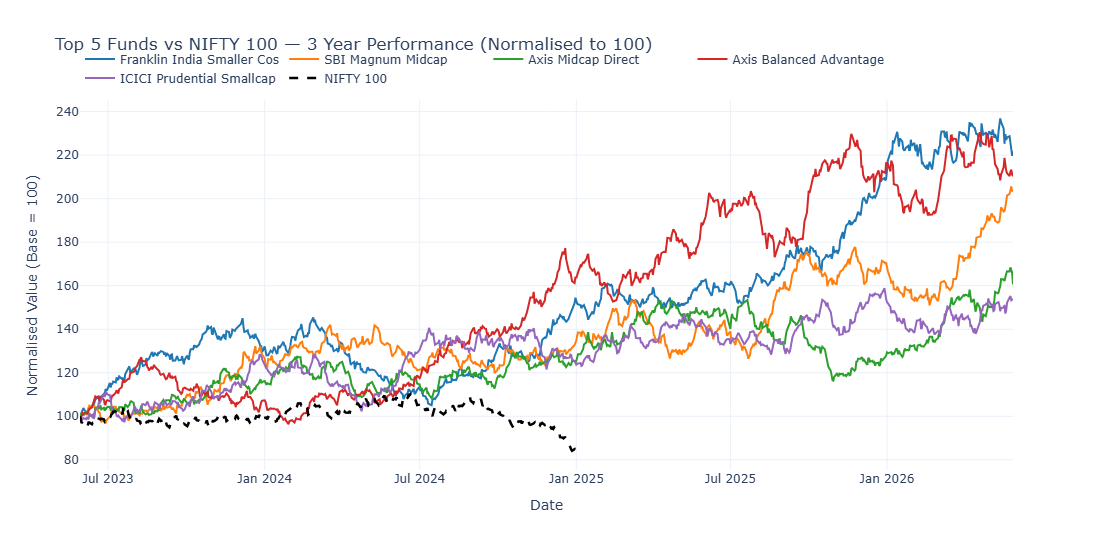


Tracking Error vs NIFTY 100:
  Franklin India Smaller Cos          -> Tracking Error: 25.15%
  SBI Magnum Midcap                   -> Tracking Error: 25.26%
  Axis Midcap Direct                  -> Tracking Error: 24.59%
  Axis Balanced Advantage             -> Tracking Error: 24.83%
  ICICI Prudential Smallcap           -> Tracking Error: 25.28%

 Chart 12 saved!


In [10]:
top5_names = df_scorecard['scheme_name'].head(5).tolist()
top5_codes = df_scorecard['amfi_code'].head(5).tolist()

cutoff = df_nav['date'].max() - pd.DateOffset(years=3)
df_top5 = df_nav[
    (df_nav['amfi_code'].isin(top5_codes)) &
    (df_nav['date'] >= cutoff)
].copy()

df_top5 = df_top5.sort_values('date')
df_top5['nav_norm'] = df_top5.groupby('scheme_name')['nav'].transform(
    lambda x: x / x.iloc[0] * 100
)

df_bench_3yr = df_bench[df_bench['date'] >= cutoff].copy()
df_bench_3yr['bench_norm'] = df_bench_3yr['index_value'] / df_bench_3yr['index_value'].iloc[0] * 100

fig = go.Figure()
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

for i, (code, name) in enumerate(zip(top5_codes, top5_names)):
    fund_plot = df_top5[df_top5['amfi_code'] == code]
    fig.add_trace(go.Scatter(
        x=fund_plot['date'],
        y=fund_plot['nav_norm'],
        name=name,
        line=dict(width=2, color=colors[i])
    ))

fig.add_trace(go.Scatter(
    x=df_bench_3yr['date'],
    y=df_bench_3yr['bench_norm'],
    name='NIFTY 100',
    line=dict(width=2.5, color='black', dash='dash')
))

fig.update_layout(
    title="Top 5 Funds vs NIFTY 100 — 3 Year Performance (Normalised to 100)",
    xaxis_title="Date",
    yaxis_title="Normalised Value (Base = 100)",
    height=550,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02)
)
fig.write_html("../reports/charts/12_benchmark_comparison.html")
fig.show()

print("\nTracking Error vs NIFTY 100:")
for code, name in zip(top5_codes, top5_names):
    fund_ret = df_returns[df_returns['amfi_code'] == code][['date','daily_return']]
    merged   = pd.merge(fund_ret, df_bench[['date','bench_return']], on='date')
    te       = (merged['daily_return'] - merged['bench_return']).std() * np.sqrt(TRADING_DAYS) * 100
    print(f"  {name[:35]:35s} -> Tracking Error: {te:.2f}%")

print("\n Chart 12 saved!")

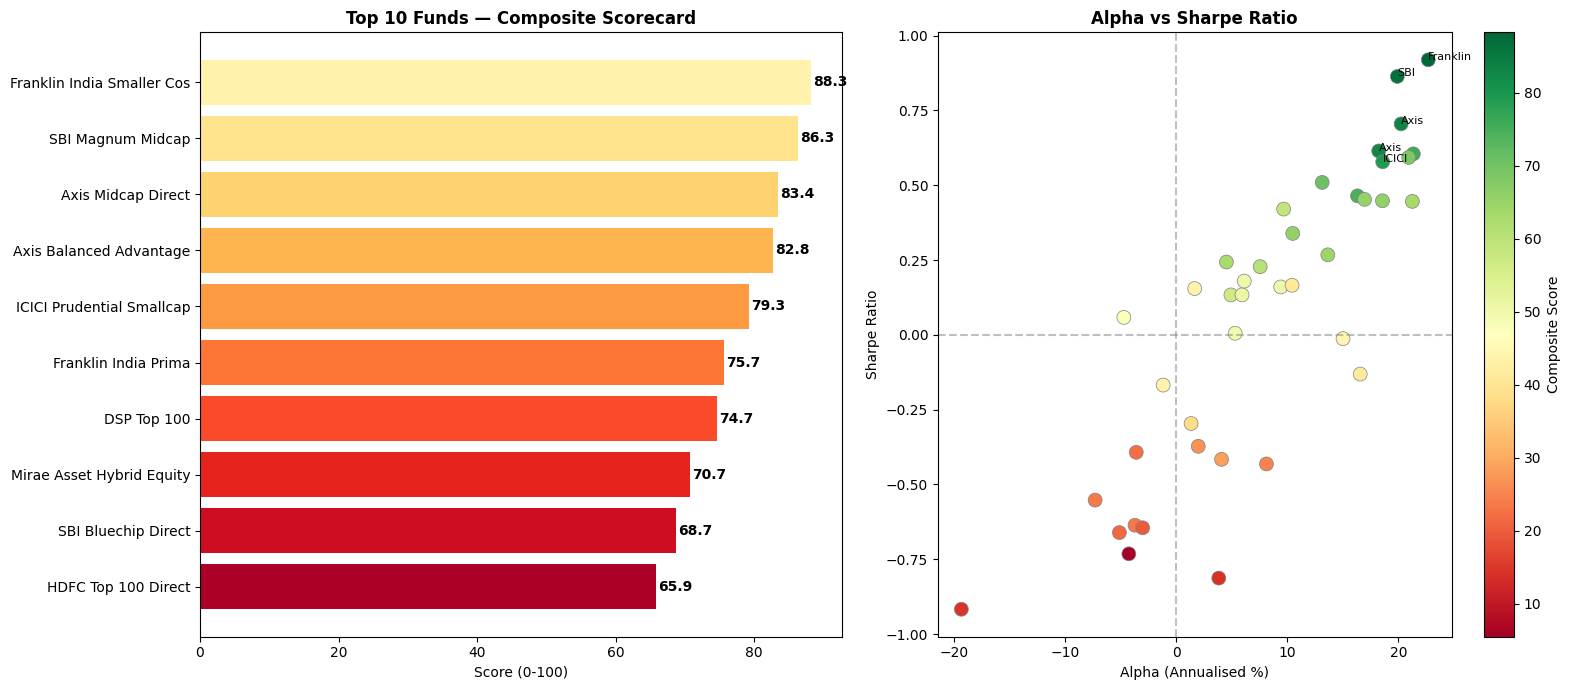

Chart 13 saved!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top10  = df_scorecard.head(10)
colors = sns.color_palette("YlOrRd_r", 10)

axes[0].barh(top10['scheme_name'][::-1], top10['score'][::-1], color=colors)
axes[0].set_title("Top 10 Funds — Composite Scorecard", fontweight='bold')
axes[0].set_xlabel("Score (0-100)")
for i, (score, name) in enumerate(zip(top10['score'][::-1], top10['scheme_name'][::-1])):
    axes[0].text(score + 0.3, i, f"{score:.1f}", va='center', fontweight='bold')

sc = axes[1].scatter(
    df_scorecard['alpha'],
    df_scorecard['sharpe_ratio'],
    c=df_scorecard['score'],
    cmap='RdYlGn',
    s=100, edgecolors='gray', linewidths=0.5
)
plt.colorbar(sc, ax=axes[1], label='Composite Score')
axes[1].set_title("Alpha vs Sharpe Ratio", fontweight='bold')
axes[1].set_xlabel("Alpha (Annualised %)")
axes[1].set_ylabel("Sharpe Ratio")
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)

for _, row in df_scorecard.head(5).iterrows():
    axes[1].annotate(
        row['scheme_name'].split()[0],
        (row['alpha'], row['sharpe_ratio']),
        fontsize=8, ha='left'
    )

plt.tight_layout()
plt.savefig("../reports/charts/13_scorecard_analysis.png", dpi=150)
plt.show()
print("Chart 13 saved!")

In [12]:
print("="*55)
print("DAY 4 PERFORMANCE ANALYTICS — COMPLETE")
print("="*55)
print(f"Daily returns computed    — {len(df_returns)} records")
print(f"CAGR computed             — {len(df_cagr)} funds")
print(f"Sharpe Ratio computed     — {len(df_sharpe)} funds")
print(f"Sortino Ratio computed    — {len(df_sortino)} funds")
print(f"Alpha & Beta computed     — {len(df_alpha_beta)} funds")
print(f"Maximum Drawdown computed — {len(df_drawdown)} funds")
print(f"Fund Scorecard saved      — fund_scorecard.csv")
print(f"Alpha Beta saved          — alpha_beta.csv")
print(f"Benchmark chart saved     — 12_benchmark_comparison.html")
print("="*55)
print(f"\nTop 3 Funds Overall:")
for _, row in df_scorecard.head(3).iterrows():
    print(f"  #{int(row['overall_rank'])} {row['scheme_name']} — Score: {row['score']}")
print("\n Ready for Day 5: Advanced Analytics!")

DAY 4 PERFORMANCE ANALYTICS — COMPLETE
Daily returns computed    — 45960 records
CAGR computed             — 40 funds
Sharpe Ratio computed     — 40 funds
Sortino Ratio computed    — 40 funds
Alpha & Beta computed     — 40 funds
Maximum Drawdown computed — 40 funds
Fund Scorecard saved      — fund_scorecard.csv
Alpha Beta saved          — alpha_beta.csv
Benchmark chart saved     — 12_benchmark_comparison.html

Top 3 Funds Overall:
  #1 Franklin India Smaller Cos — Score: 88.27
  #2 SBI Magnum Midcap — Score: 86.35
  #3 Axis Midcap Direct — Score: 83.4

 Ready for Day 5: Advanced Analytics!
